<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/sleep/solved/04_varying_intercept.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep deprivation 4 — Varying intercepts

Allow each participant to have a different baseline reaction time while keeping one common deprivation slope. This introduces partial pooling.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pandas==2.2.3" \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

Note: you may need to restart the kernel to use updated packages.


D:\Repositories\BayesShortCourse\tmp\colabenv\Scripts\python.exe: No module named pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260924
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

g++ not available, if using conda: `conda install gxx`


PyMC: 6.3.2
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


## Data

The original study contains two adaptation/training days followed by a baseline measurement and then seven nights of severe sleep restriction. You can read about the original study here: [Belenky J Sleep Res. 2003](https://doi.org/10.1046/j.1365-2869.2003.00337.x)

Following the chapter, we drop original days 0–1 and subtract 2 from the remaining day number. Therefore **`Days = 0` is the baseline measurement before sleep deprivation begins**.

That zero point is scientifically meaningful, so every model in this sequence keeps `Days` on its natural scale (no centering). The intercept prior is therefore a prior on baseline reaction time rather than reaction time at the average deprivation day.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/lme4/sleepstudy.csv"

sleep = pd.read_csv(DATA_URL).drop(columns="rownames")
sleep = sleep.loc[sleep["Days"] >= 2].copy()
sleep["Days"] = sleep["Days"] - 2
sleep["Subject"] = sleep["Subject"].astype(str)
sleep = sleep.reset_index(drop=True)

print(f"{sleep['Subject'].nunique()} participants, {len(sleep)} observations")
print(f"Days: {sleep['Days'].min()} to {sleep['Days'].max()}")
sleep.head()

18 participants, 144 observations
Days: 0 to 7


,Reaction,Days,Subject
0,250.8006,0,308
1,321.4398,1,308
2,356.8519,2,308
3,414.6901,3,308
4,382.2038,4,308


### Plotting helpers

These helper functions draw the regression and its uncertainties. There are two: one for showing population regressions and one for showing individual regressions.

#### Format colors

In [4]:
# orange mean line, blue 50% and 90% HDI bands, black observed points.
LM_VISUALS = {
    "pe_line": {"color": "C1"},
    "ci_band": {"color": "C0"},
    "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3, "s": 10},
}
PARTICIPANT_DAY = xr.Coordinates.from_pandas_multiindex(
    pd.MultiIndex.from_frame(sleep[["Subject", "Days"]], names=["participant", "day"]),
    "obs_id",
)

#### plot_population

Plot any variable against days using plot_lm. Use the standard colors and legend above.

In [5]:

def plot_population(dt, var, group="posterior"):
    """Single-panel trend of `var` against days, with all 144 raw observations."""
    pc = azp.plot_lm(
        dt,
        x="days",
        y=var,
        y_obs="Reaction",
        group=group,
        plot_dim="obs_id",
        ci_prob=(0.50, 0.90),
        ci_kind="hdi",
        point_estimate="mean",
        smooth=False,
        figure_kwargs={"figsize": (7, 4)},
        visuals={
            **LM_VISUALS,
            "xlabel": False,
            "ylabel": False,
        },
    )

    pc.facet_map("labelled_x", text="Days of sleep deprivation")
    pc.facet_map("labelled_y", text="Reaction time (ms)")
    pc.add_legend("prob", title="HDI")

    return pc

#### plot_participants

The same as plot_population but for the participants. 

In [6]:
def plot_participants(dt, group, var):
    """One panel per participant: bands for `var` against days, with that participant's data."""
    def reshape(ds):
        return ds.assign_coords(PARTICIPANT_DAY).unstack("obs_id")

    panels = xr.DataTree.from_dict({
        group: reshape(dt[group].to_dataset()),
        "observed_data": reshape(dt["observed_data"].to_dataset()),
        "constant_data": reshape(dt["constant_data"].to_dataset()),
    })

    pc = azp.plot_lm(
        panels,
        x="days",
        y=var,
        y_obs="Reaction",
        group=group,
        plot_dim="day",
        ci_prob=(0.50, 0.90),
        ci_kind="hdi",
        point_estimate="mean",
        smooth=False,
        cols=["participant"],
        col_wrap=6,
        figure_kwargs={"figsize": (11, 5.5), "sharex": True, "sharey": True},
        visuals={**LM_VISUALS, "xlabel": False, "ylabel": False},
    )

    pc.add_legend("prob", title="HDI")

    fig = pc.get_viz("figure")
    fig.supxlabel("Days of sleep deprivation")
    fig.supylabel("Reaction time (ms)")

    return pc

In [7]:
participants = sorted(sleep["Subject"].unique(), key=int)
participant_idx = sleep["Subject"].map({p: i for i, p in enumerate(participants)}).to_numpy()

## 4.1 Participant baselines

How can we let participants differ at baseline while still sharing one deprivation slope?

$$\mu_i=(\alpha+u_{0,s[i]})+\beta\,\text{Days}_i,\qquad u_{0,s}\sim N(0,\tau_0).$$

The population intercept remains baseline reaction time. Participant-specific intercepts are deviations from that baseline. We use a non-centered parameterization (`participant_intercept_z`) for more reliable sampling.

In [8]:
coords = {"obs_id": np.arange(len(sleep)), "participant": participants}

with pm.Model(coords=coords) as model:
    days = pm.Data("days", sleep["Days"].to_numpy(), dims="obs_id")
    pidx = pm.Data("participant_idx", participant_idx, dims="obs_id")

    intercept = pm.Normal("intercept", mu=250, sigma=100)
    slope = pm.Normal("slope", mu=0, sigma=20)
    sigma = pm.Exponential("sigma", lam=0.04)

    participant_intercept_sd = pm.Exponential("participant_intercept_sd", lam=0.04)
    participant_intercept_z = pm.Normal("participant_intercept_z", 0, 1, dims="participant")
    participant_intercept = pm.Deterministic(
        "participant_intercept",
        participant_intercept_sd * participant_intercept_z,
        dims="participant",
    )

    population_mu = pm.Deterministic(
        "population_mu", intercept + slope * days, dims="obs_id"
    )
    mu = pm.Deterministic(
        "mu", population_mu + participant_intercept[pidx], dims="obs_id"
    )

    pm.Normal(
        "Reaction",
        mu=mu,
        sigma=sigma,
        observed=sleep["Reaction"].to_numpy(),
        dims="obs_id",
    )

Before fitting, ask what reaction times the priors make plausible. Each panel is one participant. The bands are the prior predictive distribution of a single new reaction-time measurement on each day. The black points are that participant's data, shown only as a reference: they do not condition the prior.

Sampling: [Reaction, intercept, participant_intercept_sd, participant_intercept_z, sigma, slope]


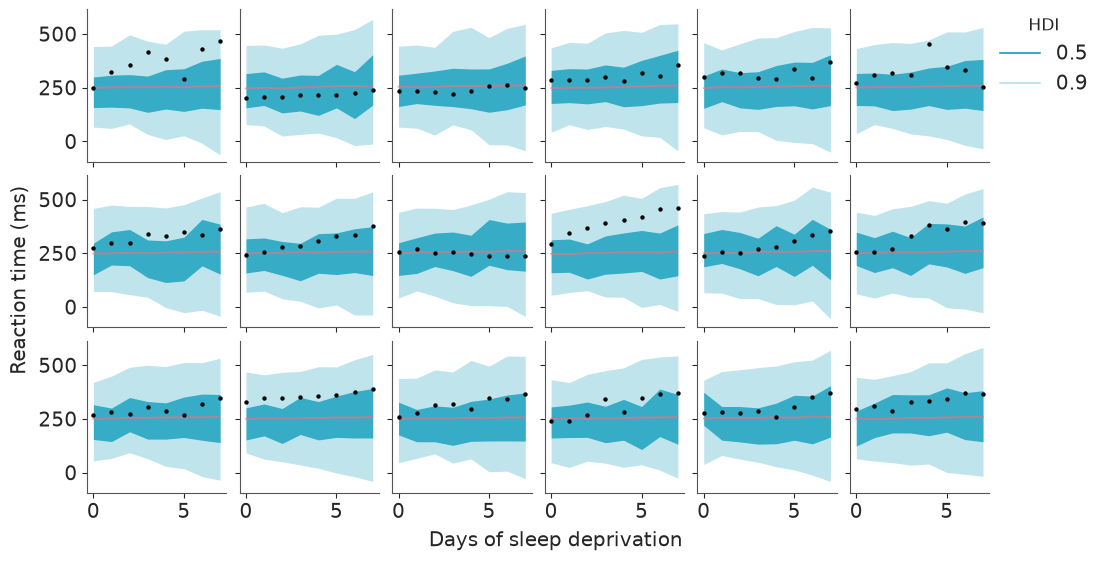

In [9]:
with model:
    prior = pm.sample_prior_predictive(
        draws=500, var_names=["Reaction"], random_seed=RANDOM_SEED
    )

plot_participants(prior, "prior_predictive", "Reaction")
plt.show()

## 4.2 Partial pooling

What does partial pooling estimate about baseline differences across participants?

Do not interpret the fit until the sampler diagnostics are acceptable: no divergences, R-hat ≤ 1.01, and bulk and tail ESS in the hundreds or more.

In [10]:
with model:
    idata = pm.sample(
        draws=1000, tune=1500, chains=4, target_accept=0.92, random_seed=RANDOM_SEED
    )

print("Divergences:", int(idata["sample_stats"]["diverging"].sum().item()))
azs.summary(
    idata, var_names=["intercept", "slope", "sigma", "participant_intercept_sd"],
    ci_prob=0.90, ci_kind="hdi", round_to=2,
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [intercept, slope, sigma, participant_intercept_sd, participant_intercept_z]


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 11 seconds.


Divergences: 0


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,267.79,11.02,250.20,285.93,527.25,772.41,1.01,0.48,0.29
slope,11.36,1.10,9.45,13.11,2767.39,2610.42,1.00,0.02,0.02
sigma,30.35,1.90,27.28,33.45,3429.20,3082.68,1.00,0.03,0.03
participant_intercept_sd,42.26,7.61,29.92,53.65,755.49,1235.49,1.00,0.28,0.18


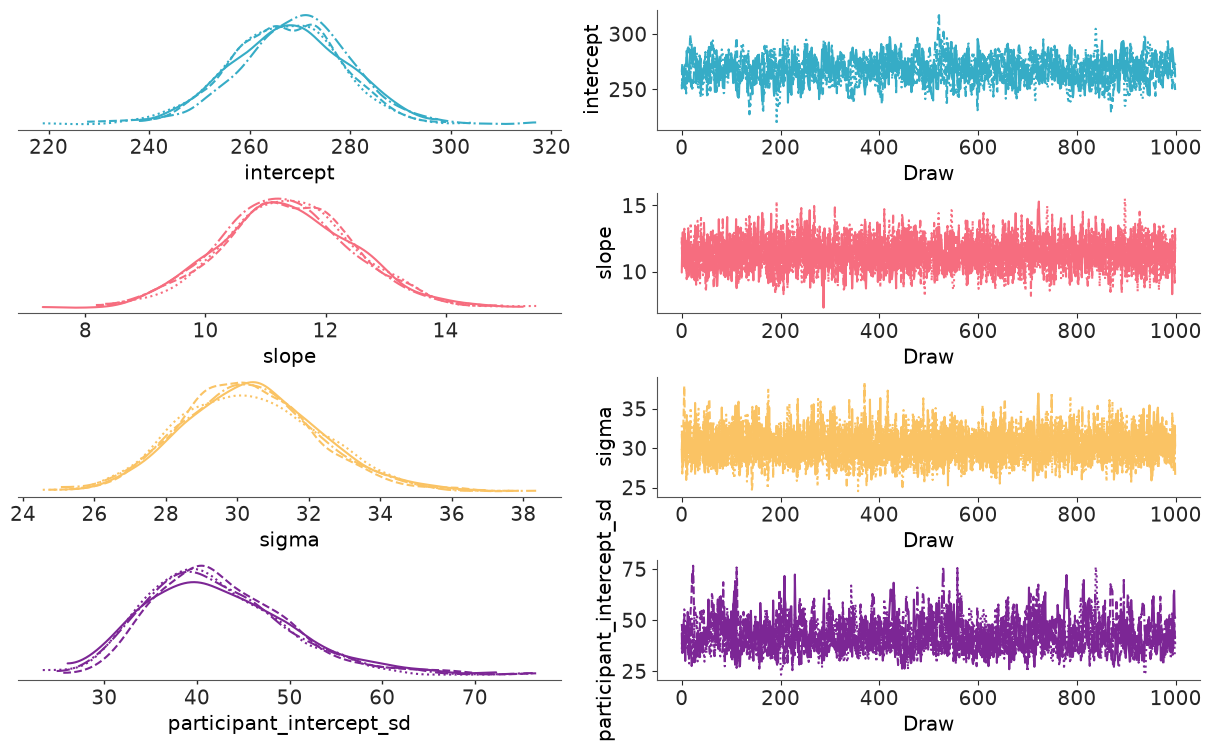

In [11]:
azp.plot_trace_dist(idata, var_names=["intercept", "slope", "sigma", "participant_intercept_sd"]);

This plot shows posterior uncertainty in the expected reaction time of a *typical* participant (all participant-specific deviations set to zero). It does not include between-participant or measurement-to-measurement variation.

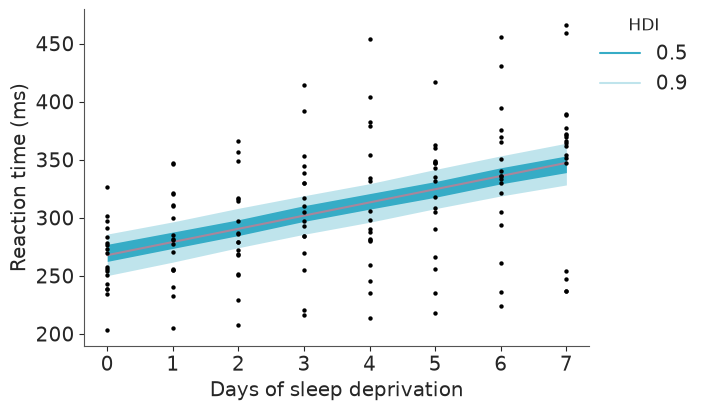

In [12]:
plot_population(idata, "population_mu")
plt.show()

Each panel shows posterior uncertainty in that participant's expected reaction time. These are mean trajectories, not new measurements. The next plot adds measurement variation.

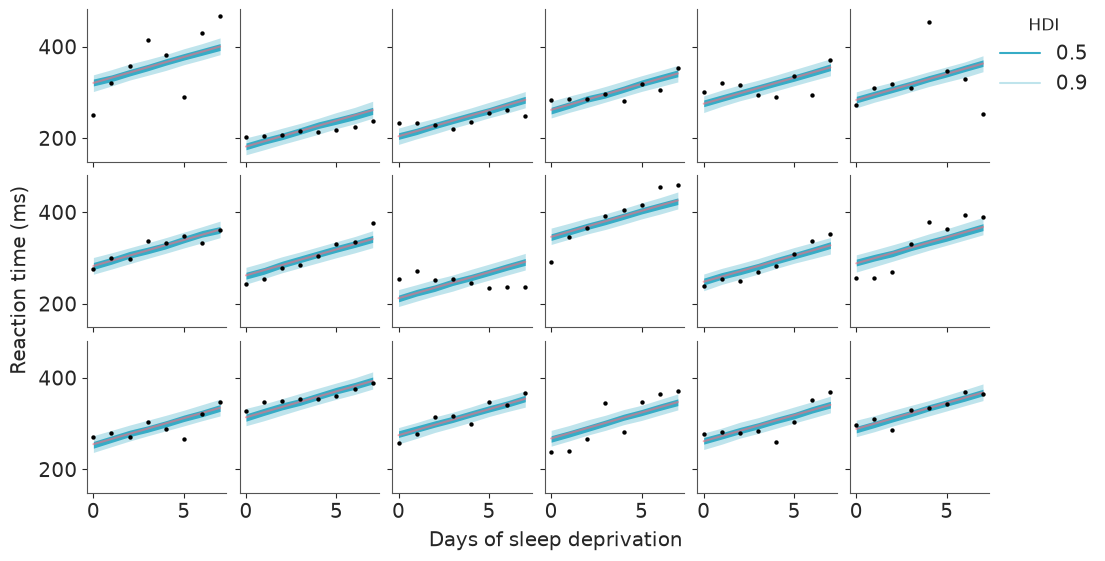

In [13]:
plot_participants(idata, "posterior", "mu")
plt.show()

## 4.3 Explaining between-person differences

Does allowing participant-specific baselines explain the systematic between-person differences in reaction time?

Now generate new reaction times from the fitted model. The layout is the same as in the prior predictive check; the difference is that these predictions are conditioned on the data. The bands are the distribution of a single new measurement for each participant and day.

Sampling: [Reaction]


D:\Repositories\BayesShortCourse\tmp\colabenv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets"
for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

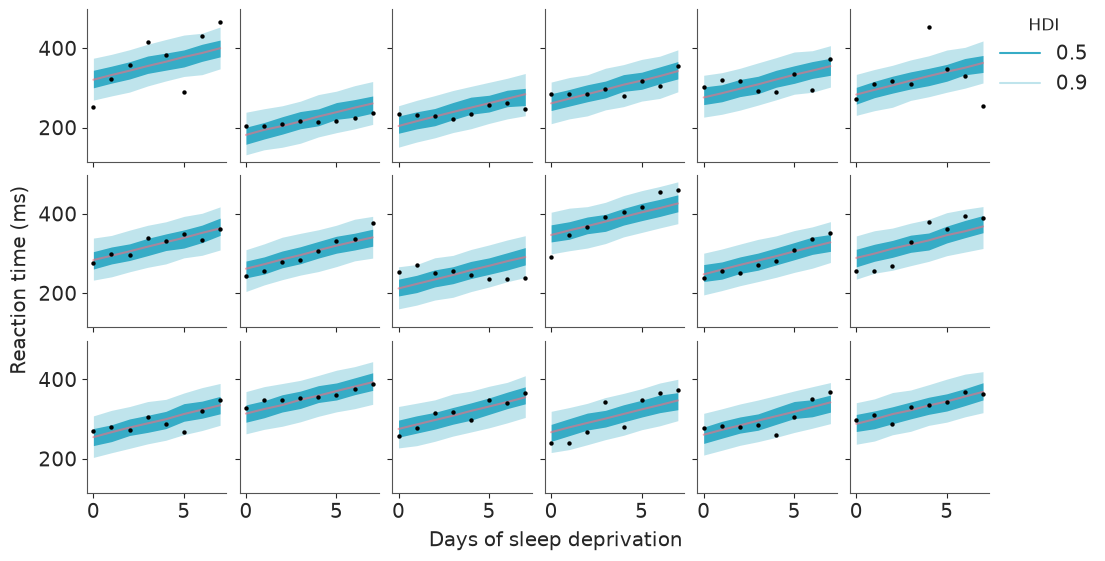

In [14]:
with model:
    pm.sample_posterior_predictive(
        idata, var_names=["Reaction"], extend_inferencedata=True, random_seed=RANDOM_SEED
    )

plot_participants(idata, "posterior_predictive", "Reaction")
plt.show()

## 4.4 Remaining trajectory differences

What remaining pattern suggests that participants also need different deprivation slopes?

Partial pooling now captures persistent baseline differences — the participant panels track each person's level much better than notebook 1's single line did. But their *slopes* are all forced parallel, and several panels show trajectories that are clearly steeper or flatter than that shared slope. The next model adds varying slopes.